In [1]:
pip install torch torchvision torchaudio scikit-learn tqdm matplotlib soundata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.0/162.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, utils as vutils

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython import display

import soundata
import librosa
import librosa.display
from IPython.display import Audio

In [3]:
torch.manual_seed(1337)

In [4]:
#device = "cuda:0" if torch.cuda.is_available() else "cpu"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA is not available. Using CPU.")

Using device: cuda:0
GPU: Tesla T4
CUDA Version: 12.4
GPU Memory: 14.74 GB


In [32]:
def helmholtz3d_exact_u(a1, a2, a3, x, y, z):
    return torch.sin(a1*torch.pi*x) * torch.sin(a2*torch.pi*y) * torch.sin(a3*torch.pi*z)

In [33]:
def relative_l2(u_pred, u_true):
    """Относительная L2 ошибка: ||u_pred - u_true|| / ||u_true||"""
    return torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)

def plot_helmholtz3d(x, y, z, u):
    x = x.detach().cpu().numpy().flatten()
    y = y.detach().cpu().numpy().flatten()
    z = z.detach().cpu().numpy().flatten()
    u = u.detach().cpu().numpy().flatten()

    u_norm = (u - u.min()) / (u.max() - u.min())

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Ключевые изменения
    scatter = ax.scatter(x, y, z, c=u_norm,
                        s=1,
                        cmap='seismic',
                        vmin=0, vmax=1,
                        alpha=0.75,
                        edgecolors='none')

    ax.set_title('U(x, y, z)', fontsize=20)
    ax.set_xlabel('x', fontsize=18, labelpad=10)
    ax.set_ylabel('y', fontsize=18, labelpad=10)
    ax.set_zlabel('z', fontsize=18, labelpad=10)

    cbar = plt.colorbar(scatter, shrink=0.8, aspect=15)
    cbar.set_label('u(x,y,z)', fontsize=16)

    plt.tight_layout()
    plt.show()


def plot_losses(loss_history, residual_history, boundary_history,
                error_history, log_iter, title_prefix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.semilogy(loss_history, label='Total Loss', linewidth=2)
    ax1.semilogy(residual_history, label='Residual Loss', alpha=0.7)
    ax1.semilogy(boundary_history, label='Boundary Loss', alpha=0.7)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss (log scale)')
    ax1.set_title(f'{title_prefix}Training Losses')

    iterations = np.arange(0, len(error_history) * log_iter, log_iter)
    ax2.semilogy(iterations, error_history, 'r-', linewidth=2, label='Relative L2 Error')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Error (log scale)')
    ax2.set_title(f'{title_prefix}Relative L2 Error')

    plt.tight_layout()
    plt.show()


def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    """Вычисление ошибки на гриде"""
    with torch.no_grad():
        model.eval()

        # Создаем coordinates tensor из сетки
        coords = torch.stack([x_grid.flatten(), y_grid.flatten(), z_grid.flatten()], dim=1)
        u_pred = model(coords)
        error = relative_l2(u_pred, u_true.flatten())
        model.train()
    return error, u_pred.reshape(x_grid.shape)


def resample_collocation_points(model, NC, domain_size=1.0):
    """
    Ресэмплирование коллокационных точек (как в статье SPINN).
    """
    # Факторизуемые координаты (lattice structure)
    N_per_axis = int(NC ** (1/3))  # Кубический корень для 3D

    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)

    xx, yy, zz = torch.meshgrid(x, y, z, indexing='ij')

    cell = (2 * domain_size) / (N_per_axis - 1)
    jitter = (torch.rand_like(xx) - 0.5) * cell

    xc = (xx + jitter).flatten()
    yc = (yy + jitter).flatten()
    zc = (zz + jitter).flatten()

    xc.requires_grad_(True)
    yc.requires_grad_(True)
    zc.requires_grad_(True)

    return xc, yc, zc

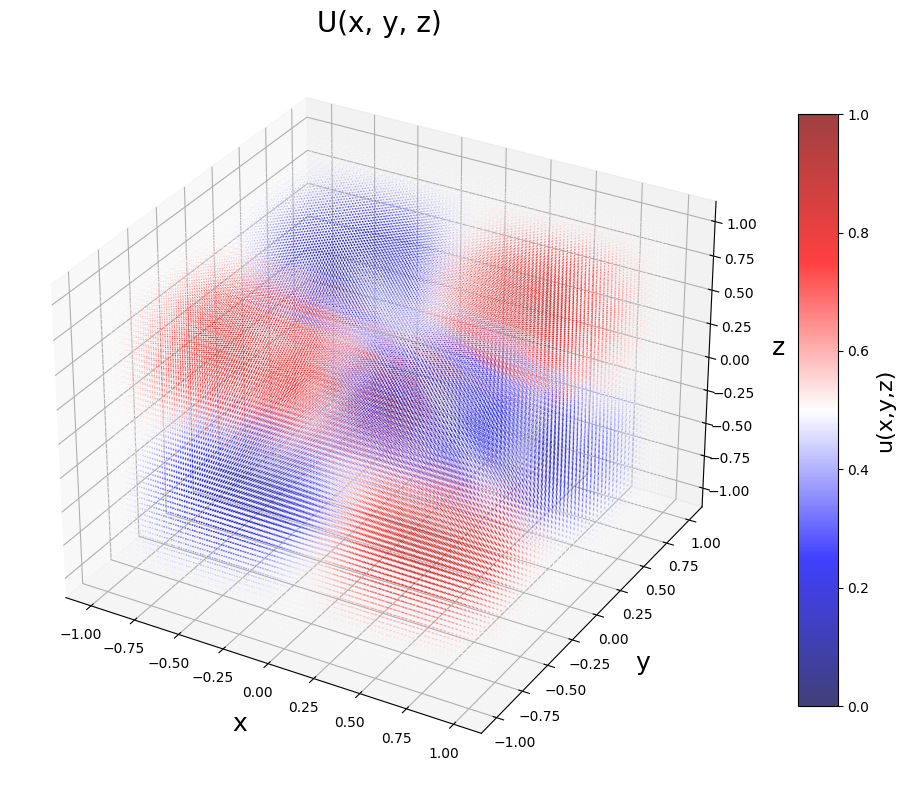

In [34]:
N_test = 50
x_test = torch.linspace(-1, 1, N_test, device=device)
y_test = torch.linspace(-1, 1, N_test, device=device)
z_test = torch.linspace(-1, 1, N_test, device=device)

xx_test, yy_test, zz_test = torch.meshgrid(x_test, y_test, z_test, indexing='ij')

u_test = helmholtz3d_exact_u(1, 1, 1, xx_test, yy_test, zz_test)

plot_helmholtz3d(xx_test, yy_test, zz_test, u_test)

In [35]:
class BaseModel(nn.Module):
    """
    Базовая модель для 3D уравнения Гельмгольца на кубе [-1,1]³.

    PDE:  ∇²u(x,y,z) + k²u(x,y,z) = q(x,y,z)
    BC:   u(x,y,z) = 0 на каждой из 6 граней куба.

    Manufactured solution: u = sin(a₁πx)sin(a₂πy)sin(a₃πz)
    """

    def __init__(self,
                 x_min: float = -1., x_max: float = 1.,
                 y_min: float = -1., y_max: float = 1.,
                 z_min: float = -1., z_max: float = 1.,
                 k: float = 1.0,
                 a1: int = 1, a2: int = 1, a3: int = 1,
                 N: int = 32,
                 device: torch.device = None):
        super().__init__()
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max
        self.z_min, self.z_max = z_min, z_max
        self.N = N
        self.k = k  # волновое число
        self.a1, self.a2, self.a3 = a1, a2, a3
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.mse = nn.MSELoss(reduction="mean")

        # Граничные точки (6 граней куба)
        self._init_boundary_points()

    def _init_boundary_points(self):
        """Инициализация точек на 6 гранях куба."""
        N = self.N

        # Создаем линейные сетки для каждой оси
        lin_x = torch.linspace(self.x_min, self.x_max, N)
        lin_y = torch.linspace(self.y_min, self.y_max, N)
        lin_z = torch.linspace(self.z_min, self.z_max, N)

        # Грань 1: x = x_min (левая грань)
        yy, zz = torch.meshgrid(lin_y, lin_z, indexing='ij')
        x_bc1 = torch.full_like(yy, self.x_min).reshape(-1, 1)
        y_bc1 = yy.reshape(-1, 1)
        z_bc1 = zz.reshape(-1, 1)

        # Грань 2: x = x_max (правая грань)
        yy, zz = torch.meshgrid(lin_y, lin_z, indexing='ij')
        x_bc2 = torch.full_like(yy, self.x_max).reshape(-1, 1)
        y_bc2 = yy.reshape(-1, 1)
        z_bc2 = zz.reshape(-1, 1)

        # Грань 3: y = y_min (нижняя грань)
        xx, zz = torch.meshgrid(lin_x, lin_z, indexing='ij')
        x_bc3 = xx.reshape(-1, 1)
        y_bc3 = torch.full_like(xx, self.y_min).reshape(-1, 1)
        z_bc3 = zz.reshape(-1, 1)

        # Грань 4: y = y_max (верхняя грань)
        xx, zz = torch.meshgrid(lin_x, lin_z, indexing='ij')
        x_bc4 = xx.reshape(-1, 1)
        y_bc4 = torch.full_like(xx, self.y_max).reshape(-1, 1)
        z_bc4 = zz.reshape(-1, 1)

        # Грань 5: z = z_min (передняя грань)
        xx, yy = torch.meshgrid(lin_x, lin_y, indexing='ij')
        x_bc5 = xx.reshape(-1, 1)
        y_bc5 = yy.reshape(-1, 1)
        z_bc5 = torch.full_like(xx, self.z_min).reshape(-1, 1)

        # Грань 6: z = z_max (задняя грань)
        xx, yy = torch.meshgrid(lin_x, lin_y, indexing='ij')
        x_bc6 = xx.reshape(-1, 1)
        y_bc6 = yy.reshape(-1, 1)
        z_bc6 = torch.full_like(xx, self.z_max).reshape(-1, 1)

        # Регистрируем как buffers
        for i, (x_bc, y_bc, z_bc) in enumerate([
            (x_bc1, y_bc1, z_bc1), (x_bc2, y_bc2, z_bc2),
            (x_bc3, y_bc3, z_bc3), (x_bc4, y_bc4, z_bc4),
            (x_bc5, y_bc5, z_bc5), (x_bc6, y_bc6, z_bc6)
        ], 1):
            coords = torch.cat([x_bc, y_bc, z_bc], dim=-1).to(self.device)
            self.register_buffer(f"coords_bc{i}", coords)
            self.register_buffer(f"zeros_bc{i}", torch.zeros(coords.shape[0], 1).to(self.device))

    # Физика задачи
    def reference_solution(self, x, y, z):
        """
        Аналитическое решение (manufactured solution):
        u(x,y,z) = sin(a₁πx) * sin(a₂πy) * sin(a₃πz)
        """
        return (torch.sin(self.a1 * np.pi * x) *
                torch.sin(self.a2 * np.pi * y) *
                torch.sin(self.a3 * np.pi * z))

    def function_of_source(self, x, y, z):
        """
        Правая часть q(x,y,z), полученная из точного решения:
        Из уравнения Гельмгольца: ∇²u + k²u = q
        Подставляя manufactured solution:
        q = -(a₁π)²u - (a₂π)²u - (a₃π)²u + k²u
        """
        u = self.reference_solution(x, y, z)
        laplacian_term = (-(self.a1 * np.pi)**2 -
                         (self.a2 * np.pi)**2 -
                         (self.a3 * np.pi)**2) * u
        return laplacian_term + self.k**2 * u

    def calculate_loss(self, states: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        states: (B, 3) с колонками [x, y, z]
        Возвращает (loss_PDE, loss_BC)
        """
        x, y, z = states[:, 0], states[:, 1], states[:, 2]
        loss_pde = self.calculate_pde_loss(x, y, z)
        loss_bc = self.calculate_bc_loss()
        return loss_pde, loss_bc

    def calculate_pde_loss(self, x: torch.Tensor, y: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        """
        MSE по PDE-резидуалу: r = ∇²u + k²u - q(x,y,z)

        Использует forward-mode AD для эффективного вычисления производных.
        В статье показано, что для SPINN forward-mode быстрее reverse-mode!

        Уравнение Гельмгольца:
        ∂²u/∂x² + ∂²u/∂y² + ∂²u/∂z² + k²u = q
        """
        # Клонируем и требуем градиенты для forward-mode AD
        x = x.clone().detach().requires_grad_(True)
        y = y.clone().detach().requires_grad_(True)
        z = z.clone().detach().requires_grad_(True)

        # Формируем координаты и вычисляем u
        coords = torch.stack([x, y, z], dim=1)  # (B, 3)
        u = self.forward(coords)  # (B,)

        # Первые производные (используем forward-mode AD)
        u_x = self._compute_gradient(u, x)  # ∂u/∂x
        u_y = self._compute_gradient(u, y)  # ∂u/∂y
        u_z = self._compute_gradient(u, z)  # ∂u/∂z

        # Вторые производные
        u_xx = self._compute_gradient(u_x, x)  # ∂²u/∂x²
        u_yy = self._compute_gradient(u_y, y)  # ∂²u/∂y²
        u_zz = self._compute_gradient(u_z, z)  # ∂²u/∂z²

        # Лапласиан: ∇²u = ∂²u/∂x² + ∂²u/∂y² + ∂²u/∂z²
        laplace_u = u_xx + u_yy + u_zz

        # Источник q(x,y,z)
        q = self.function_of_source(x, y, z)

        # Резидуал уравнения Гельмгольца: ∇²u + k²u - q = 0
        residual = laplace_u + self.k**2 * u - q

        return self.mse(residual, torch.zeros_like(residual))

    @staticmethod
    def _compute_gradient(output: torch.Tensor, input_var: torch.Tensor) -> torch.Tensor:
        """
        Вычисляет градиент output по input_var используя forward-mode AD.

        Forward-mode AD эффективен когда выход - вектор большой размерности,
        а вход - скаляр, что как раз наш случай в SPINN!
        """
        grad = torch.autograd.grad(
            outputs=output,
            inputs=input_var,
            grad_outputs=torch.ones_like(output),
            create_graph=True,
            retain_graph=True
        )[0]
        return grad


    def calculate_bc_loss(self) -> torch.Tensor:
        """
        MSE по Дирихле на 6 гранях: u=0.
        """
        preds = []
        targets = []

        for i in range(1, 7):
            coords_bc = getattr(self, f"coords_bc{i}")
            zeros = getattr(self, f"zeros_bc{i}")

            u_bc = self.forward(coords_bc)
            if u_bc.dim() == 1:
                u_bc = u_bc.unsqueeze(-1)
            preds.append(u_bc)
            targets.append(zeros)

        return sum(self.mse(p, t) for p, t in zip(preds, targets))

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        """
        Должна быть реализована в наследнике.
        Ожидает coords.shape == (B, 3) с [x, y, z]; возвращает (B, 1) или (B,).
        """
        raise NotImplementedError("Реализуйте forward в наследнике.")

In [71]:
# YOUR CODE:
# Напишите свою реализацию SPINN

class BaseSPINN(BaseModel):
    """
    Separable Physics-Informed Neural Network (SPINN) для уравнения Гельмгольца.

    Архитектура согласно статье Cho et al. (2023):
    - 3 независимые body-сети: f^(i): ℝ → ℝ^r (одна для каждой координаты)
    - Feature merging (CP-decomposition): u = Σ_{j=1}^r ∏_{i=1}^3 f_j^(i)(x_i)
    - Forward-mode AD для эффективного вычисления производных

    Параметры:
        rank: r - ранг декомпозиции (размер выходного вектора каждой body-сети)
        hidden_dim: размерность скрытых слоев
        n_hidden_layers: количество скрытых слоев в каждой body-сети
    """
    def __init__(self, rank=8, hidden_dim=32, n_hidden_layers=3, **kwargs):
        super().__init__(**kwargs)
        self.rank = rank
        self.hidden_dim = hidden_dim
        self.n_hidden_layers = n_hidden_layers

        def body_foo():
            layers = []
            in_dim = 1
            for i in range(self.n_hidden_layers):
                layers.append(nn.Linear(in_dim, self.hidden_dim))
                layers.append(nn.Tanh())
                in_dim = self.hidden_dim
            layers.append(nn.Linear(in_dim, self.rank))
            net = nn.Sequential(*layers)
            net.apply(init_tanh_)
            return net
            
        self.body_net_x = body_foo()
        self.body_net_y = body_foo()
        self.body_net_z = body_foo()

    def forward(self, coordinates: torch.Tensor):
        x = coordinates[:, 0:1]
        y = coordinates[:, 1:2]
        z = coordinates[:, 2:3]
        f_x = self.body_net_x(x)
        f_y = self.body_net_y(y)
        f_z = self.body_net_z(z)
        u = torch.sum(f_x * f_y * f_z, dim=1)
        
        return u
        
        
def init_tanh_(m: nn.Module):
    """
    Инициализация весов для tanh активации.
    Xavier uniform с gain для tanh.
    """
    # TODO: Реализуйте инициализацию весов для tanh активации.
    if isinstance(m, nn.Linear):
        w = m.weight
        nn.init.xavier_uniform_(w, gain=nn.init.calculate_gain("tanh"))
        if m.bias is not None:
            nn.init.zeros_(m.bias)
        

In [72]:
def train_spinn(model,
                x_test, y_test, z_test, u_test,  # для валидации
                epochs=30000,
                adam_epochs=20000,
                lbfgs_epochs=10000,
                log_iter=100,
                resample_iter=100,
                NC=64**3,
                domain_size=1.0,
                device='cuda'):
    """
    Обучение SPINN модели для уравнения Гельмгольца.

    Args:
        model: BaseSPINN модель
        optimizer: оптимизатор
        x_test, y_test, z_test, u_test: тестовая сетка для валидации
        epochs: количество эпох
        log_iter: частота логирования
        resample_iter: частота ресэмплирования точек коллокации
        NC: количество коллокационных точек
        domain_size: размер области [-domain_size, domain_size]³
        device: устройство
    """

    history = {
        'loss': [],
        'residual': [],
        'boundary': [],
        'error': []
    }

    best_error = float('inf')
    best_u = None
    best_state_dict = None

    
    optimazer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimazer_adam, step_size=5000, gamma=0.9)
    
    pbar = trange(1, adam_epochs + 1)
    xc, yc, zc = resample_collocation_points(model, NC, domain_size)

    for epoch in pbar:

        # Ресэмплирование коллокационных точек (как в статье, каждые 100 эпох)
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = resample_collocation_points(model, NC, domain_size)

        # Шаг обучения
        optimazer_adam.zero_grad()

        # Формируем координаты для модели
        coords = torch.stack([xc, yc, zc], dim=1)
        coords.requires_grad_(True)

        # Вычисляем лоссы через интерфейс BaseModel
        loss_pde, loss_bc = model.calculate_loss(coords)
        loss = loss_pde + loss_bc

        loss.backward()
        optimazer_adam.step()

        # Сохраняем историю
        history['loss'].append(loss.item())
        history['residual'].append(loss_pde.item())
        history['boundary'].append(loss_bc.item())

        # Логирование и визуализация
        if epoch % log_iter == 0:

            # Вычисляем ошибку на тестовой сетке
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history['error'].append(error.item())

            # Обновляем лучший результат
            if error < best_error:
                best_error = error
                best_u = u_pred.clone()
                best_state_dict = model.state_dict().copy()

            # Очищаем вывод и показываем графики
            display.clear_output(wait=True)

            # Визуализация лоссов
            plot_losses(history['loss'], history['residual'],
                       history['boundary'], history['error'], log_iter)

            # Если это лучший результат, показываем решение
            if error == best_error:
                print(f"New best error: {best_error:.2e}")
                plot_helmholtz3d(x_test, y_test, z_test, u_pred)

            # Обновляем progress bar
            pbar.set_description(
                f'Loss: {loss.item():.2e} '
                f'(PDE: {loss_pde.item():.2e}, BC: {loss_bc.item():.2e}) | '
                f'Error: {error.item():.2e} | Best: {best_error:.2e}'
            )

    
    print(f'\nTraining completed! Best error: {best_error:.2e}')

    model.load_state_dict(best_state_dict)
    
    optimazer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=20,
        max_eval=50,
        history_size=100,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        line_search_fn="strong_wolfe"
    )
    
    xc, yc, zc = resample_collocation_points(model, NC * 2, domain_size)
    pbar = trange(1, lbfgs_epochs + 1)

    for epoch in pbar:
        # Ресэмплирование коллокационных точек (как в статье, каждые 100 эпох)
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = resample_collocation_points(model, NC * 2, domain_size)

        def foo():
            optimazer_lbfgs.zero_grad()
            coords = torch.stack([xc, yc, zc], dim=1)
            loss_pde, loss_bc = model.calculate_loss(coords)
            loss = loss_pde + loss_bc
            loss.backward()
            return loss
            
        loss = optimazer_lbfgs.step(foo)

        with torch.no_grad():
            coords = torch.stack([xc, yc, zc], dim=1)
            coords.requires_grad_(True)
            loss_pde, loss_bc = model.calculate_loss(coords)
            total_loss = loss_pde + loss_bc

        
        # Сохраняем историю
        history['loss'].append(loss.item())
        history['residual'].append(loss_pde.item())
        history['boundary'].append(loss_bc.item())
        
        # Логирование и визуализация
        if epoch % log_iter == 0:

            # Вычисляем ошибку на тестовой сетке
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history['error'].append(error.item())

            # Обновляем лучший результат
            if error < best_error:
                best_error = error
                best_u = u_pred.clone()
                best_state_dict = model.state_dict().copy()

            # Очищаем вывод и показываем графики
            display.clear_output(wait=True)

            # Визуализация лоссов
            plot_losses(history['loss'], history['residual'],
                       history['boundary'], history['error'], log_iter)

            # Если это лучший результат, показываем решение
            if error == best_error:
                print(f"New best error: {best_error:.2e}")
                plot_helmholtz3d(x_test, y_test, z_test, u_pred)

            # Обновляем progress bar
            pbar.set_description(
                f'Loss: {loss.item():.2e} '
                f'(PDE: {loss_pde.item():.2e}, BC: {loss_bc.item():.2e}) | '
                f'Error: {error.item():.2e} | Best: {best_error:.2e}'
            )

    model.load_state_dict(best_state_dict)
    final_error, final_u = compute_error_on_grid(model, x_test, y_test, z_test, u_test) 
    
    display.clear_output(wait=True)
    plot_losses(history['loss'], history['residual'],
               history['boundary'], history['error'], log_iter,
               title_prefix="Final ")

    if best_u is not None:
        print("\nBest solution:")
        plot_helmholtz3d(x_test, y_test, z_test, best_u)

    return history, best_error, best_u

In [73]:
EPOCHS = 1000
LOG_ITER = 100
RESAMPLE_ITER = 100  # как в статье
#NC = 64**3
NC = 8192
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [74]:
model = BaseSPINN(
    rank=32,
    hidden_dim=64,
    n_hidden_layers=4,
    N=32,
    k=1.0,
    a1=1, a2=1, a3=1
).to(device)

model.apply(init_tanh_)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

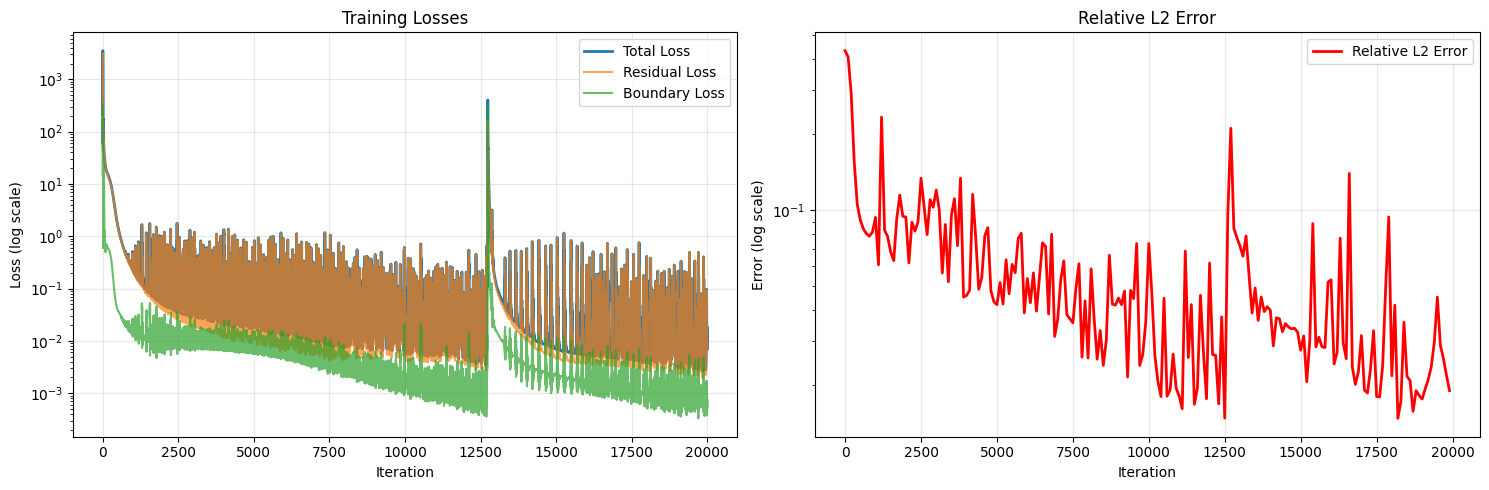


Training completed! Best error: 1.48e-02


  0%|          | 0/10000 [00:00<?, ?it/s]

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [75]:
history, best_error, best_u = train_spinn(
    model=model,
    x_test=xx_test,
    y_test=yy_test,
    z_test=zz_test,
    u_test=u_test,
    epochs=30000,
    adam_epochs=20000,        # количество эпох для Adam
    lbfgs_epochs=10000,      # количество эпох для LBFGS
    log_iter=LOG_ITER,
    resample_iter=RESAMPLE_ITER,
    NC=NC,
    domain_size=1.0,
    device=device
)


In [76]:
mse = ((u_test.cpu().numpy() - best_u.cpu().numpy()) ** 2).mean()

assert mse <= 5e-3 # 0.5 * 2 балла
assert mse <= 5e-4 # 0.6 * 2 балла
assert mse <= 1e-5 # 0.7 * 2 балла
assert mse <= 5e-6 # 0.8 * 2 балла
assert mse <= 1e-7 # 0.9 * 2 балла
assert mse <= 5e-8 # 1 * 2 балла

AssertionError: 

In [77]:
mse

0.00022931876

In [80]:
from IPython.display import FileLink

torch.save(model.state_dict(), "best_weights.pth")
FileLink("best_weights.pth")

/kaggle/working/best_weights.pth

In [5]:
dataset = soundata.initialize('urbansound8k')
dataset.download()
dataset.validate()

example_clip = dataset.choice_clip()
print(example_clip)

INFO: Downloading ['all', 'index']. Index is being stored in /usr/local/lib/python3.11/dist-packages/soundata/datasets/indexes, and the rest of files in /root/sound_datasets/urbansound8k
INFO: [all] downloading UrbanSound8K.tar.gz
5.61GB [10:48, 9.28MB/s]                                
INFO: [index] downloading urbansound8k_index_1.0.json
1.15MB [00:02, 574kB/s]                             
100%|██████████| 8732/8732 [00:16<00:00, 520.67it/s]
INFO: Success: the dataset is complete and all files are valid.
INFO: --------------------


Clip(
  audio_path="/root/sound_datasets/urbansound8k/audio/fold6/135160-8-0-1.wav",
  clip_id="135160-8-0-1",
  audio: The clip's audio
            * np.ndarray - audio signal
            * float - sample rate,
  class_id: The clip's class id.
            * int - integer representation of the class label (0-9). See Dataset Info in the documentation for mapping,
  class_label: The clip's class label.
            * str - string class name: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, street_music,
  fold: The clip's fold.
            * int - fold number (1-10) to which this clip is allocated. Use these folds for cross validation,
  freesound_end_time: The clip's end time in Freesound.
            * float - end time in seconds of the clip in the original freesound recording,
  freesound_id: The clip's Freesound ID.
            * str - ID of the freesound.org recording from which this clip was taken,
  freesound_start_time: T

In [6]:
DATASET_PATH = '/root/sound_datasets/urbansound8k'

# Загрузим метаданные
metadata = pd.read_csv(os.path.join(DATASET_PATH, 'metadata', 'UrbanSound8K.csv'))

print(f"Всего примеров: {len(metadata)}")
print(f"\nРаспределение по классам:")
print(metadata['class'].value_counts().sort_index())

metadata.head()

Всего примеров: 8732

Распределение по классам:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


Sample: 196075-2-0-0.wav
Class: children_playing
Fold: 7



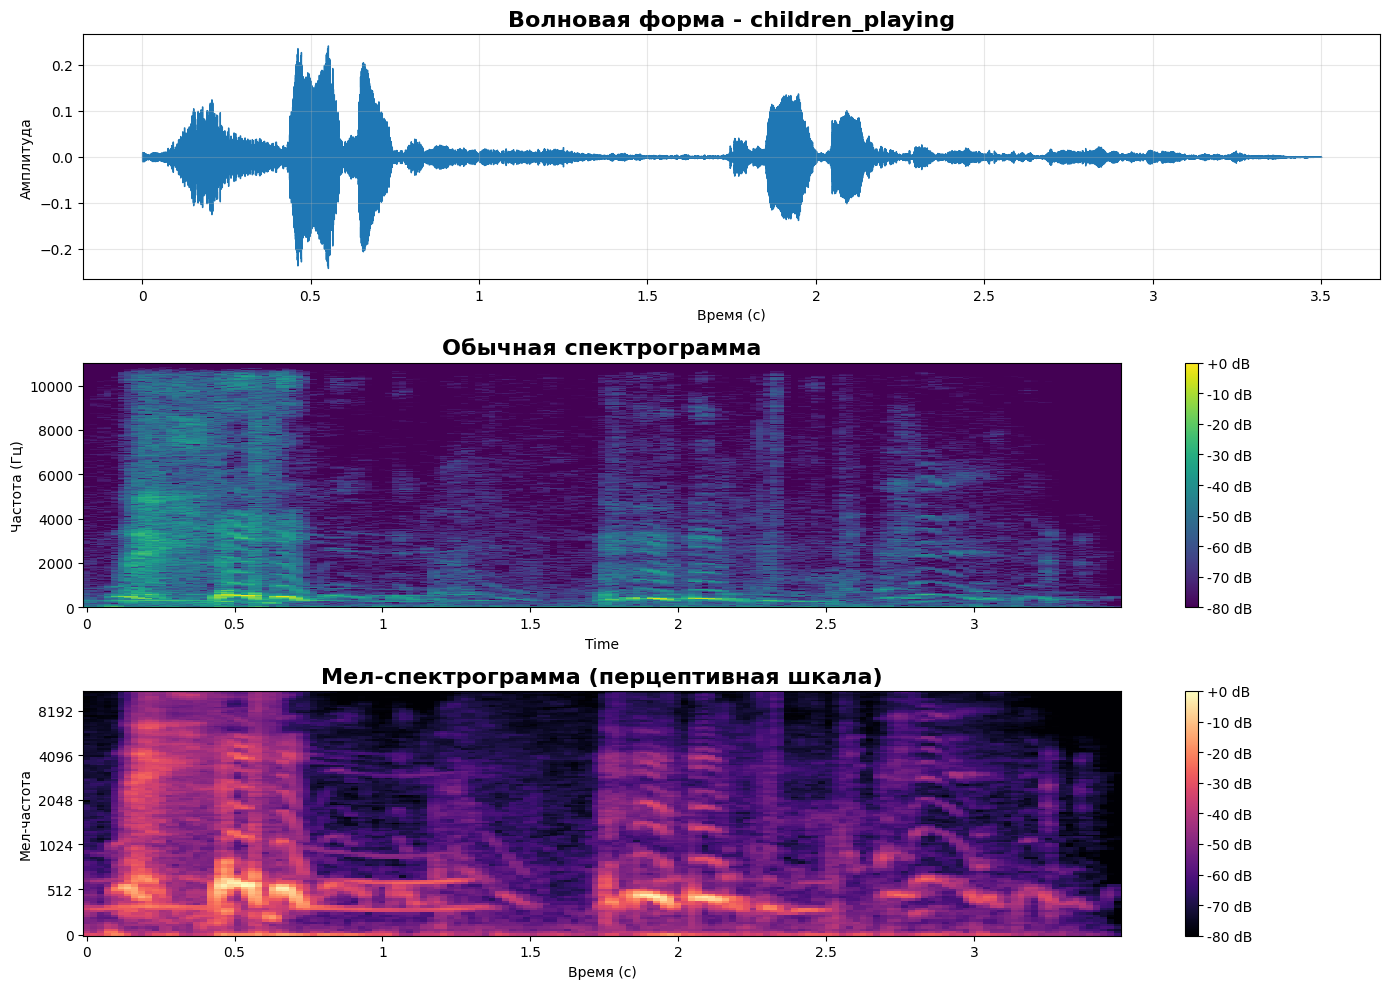


Послушай аудио ниже:


In [7]:
def plot_waveform_and_spectrogram(audio_path, class_name):
    """
    Загрузим аудио и отобразим:
    1. Волну (форма сигнала)
    2. Обычный спектрограмму
    3. Мел-спектрограмму
    """
    # Как работаем с либросой
    y, sr = librosa.load(audio_path, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # 1. Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f'Волновая форма - {class_name}', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Время (с)')
    axes[0].set_ylabel('Амплитуда')
    axes[0].grid(True, alpha=0.3)

    # 2. Обычная спектрограмма
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='viridis')
    axes[1].set_title('Обычная спектрограмма', fontsize=16, fontweight='bold')
    axes[1].set_ylabel('Частота (Гц)')
    fig.colorbar(img1, ax=axes[1], format='%+2.0f dB')

    # 3. Мел-спектрограмма
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[2], cmap='magma')
    axes[2].set_title('Мел-спектрограмма (перцептивная шкала)', fontsize=16, fontweight='bold')
    axes[2].set_ylabel('Мел-частота')
    axes[2].set_xlabel('Время (с)')
    fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

    return y, sr


# Возьмем случайный пример
random_idx = np.random.randint(0, len(metadata))
sample = metadata.iloc[random_idx]

audio_path = os.path.join(DATASET_PATH, 'audio', f'fold{sample.fold}', sample.slice_file_name)
class_name = sample['class']

print(f"Sample: {sample.slice_file_name}")
print(f"Class: {class_name}")
print(f"Fold: {sample.fold}\n")

# Заплотим визуализации
y, sr = plot_waveform_and_spectrogram(audio_path, class_name)

# Проиграем аудио
print("\nПослушай аудио ниже:")
Audio(y, rate=sr)

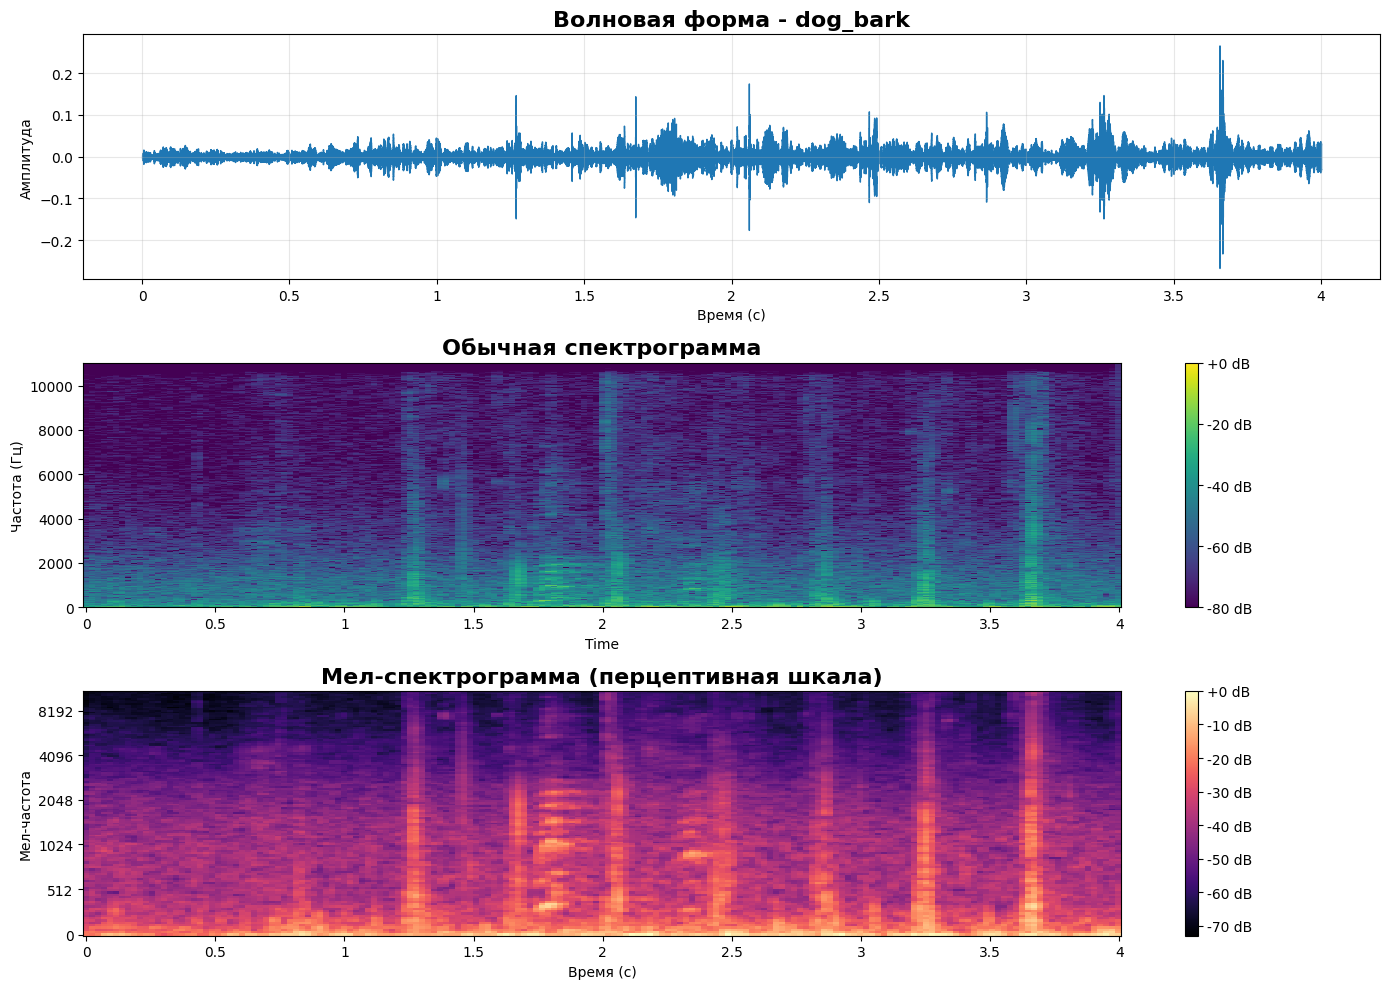

In [8]:
target_class = 'dog_bark'

class_samples = metadata[metadata['class'] == target_class]
sample = class_samples.sample(1).iloc[0]

audio_path = os.path.join(DATASET_PATH, 'audio', f'fold{sample.fold}', sample.slice_file_name)
y, sr = plot_waveform_and_spectrogram(audio_path, target_class)

Audio(y, rate=sr)

In [9]:
from pathlib import Path

class UrbanSoundDataset(Dataset):
    def __init__(self, metadata, dataset_path, target_length=4, sr=22050, n_mels=128, augment=False):
        """
        TODO: сохранить входные параметры как атрибуты и подготовить вспомогательные структуры.
        Подсказки:
        - нормализуйте индекс metadata, чтобы удобно обращаться по номеру
        - посчитайте целевое число сэмплов аудио (target_length * sr)
        - настройте LabelEncoder: fit_transform по столбцу 'class', сохраните классы и их количество
        - при желании можно выводить информацию о датасете (кол-во сэмплов, список классов)
        """
        self.metadata = metadata.reset_index(drop=True)
        self.dataset_path = Path(dataset_path)
        self.target_length = target_length
        self.sr = sr
        self.n_mels = n_mels
        self.augment = augment

        self.target_samples = target_length * sr
        
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.metadata['class'])
        self.classes = self.label_encoder.classes_
        self.num_classes = len(self.classes)

    def __len__(self):
        """
        TODO: вернуть количество доступных сэмплов.
        Подсказка: используйте длину сохранённого DataFrame.
        """
        return len(self.metadata)

    def load_audio(self, file_path):
        """
        TODO: загрузить аудио с помощью librosa.load с нужной частотой дискретизации и длительностью.
        Подсказки:
        - если сигнал короче нужной длины, дополните нулями (np.pad)
        - если длиннее — обрежьте до target_samples
        - верните обработанный сигнал numpy-массивом
        """
        y, sr = librosa.load(file_path, sr=self.sr)
        
        if len(y) < self.target_samples:
            y = np.pad(y, (0, self.target_samples - len(y)), mode='constant')
        elif len(y) > self.target_samples:
            y = y[:self.target_samples]

        return y
            

    def extract_mel_spectrogram(self, y):
        """
        TODO: построить мел-спектрограмму (librosa.feature.melspectrogram) и перевести в dB.
        Подсказки:
        - используйте сохранённые параметры sr, n_mels, фиксируйте n_fft, hop_length, fmax
        - нормализуйте мел-спектрограмму при необходимости в __getitem__
        """
        mel_spec = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels, n_fft=2048, hop_length=512, fmax=self.sr // 2.0 )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        return mel_spec_db
        

    def augment_audio(self, y):
        """
        TODO: реализовать опциональные аугментации (выполнять только при обучении).
        Идеи:
        - случайный сдвиг сигнала (np.roll) на диапазон [-sr, sr]
        - добавление белого шума (np.random.randn)
        Верните модифицированный сигнал.
        """
        y_augment = y.copy()
        y_augment = np.roll(y_augment, np.random.randint(-1 * self.sr, self.sr))
        white_noise = np.random.randn(len(y_augment)) * 0.005
        y_augment = y_augment + white_noise
        
        return y_augment

    def __getitem__(self, idx):
        """
        TODO: собрать один элемент выборки.
        Шаги:
        1. Найдите строку metadata по idx и сформируйте path: dataset_path/audio/fold{row.fold}/row.slice_file_name
        2. Загрузите аудио через load_audio
        3. При включённой аугментации примените augment_audio
        4. Постройте мел-спектрограмму, нормализуйте (z-score) и превратите в torch.FloatTensor
        5. Добавьте размерность канала (unsqueeze(0))
        6. Верните пару (мел-спектрограмма, метка класса) где метка — torch.LongTensor
        """
        row = self.metadata.iloc[idx]
        audio_path = (
            self.dataset_path
            / "audio"
            / f"fold{row['fold']}"
            / row["slice_file_name"]
        )
        audio = self.load_audio(audio_path)
        if self.augment:
            audio = self.augment_audio(audio)
            
        mel_spec = self.extract_mel_spectrogram(audio)
        mel_spec = (mel_spec - mel_spec.mean()) / (mel_spec.std() + 1e-6) 
        mel_tensor = torch.FloatTensor(mel_spec)
        mel_tensor = mel_tensor.unsqueeze(0)
        
        return mel_tensor, torch.tensor(self.labels[idx], dtype=torch.long)

        


In [10]:
test_fold = 10
test_df = metadata[metadata['fold'] == test_fold]
train_val_df = metadata[metadata['fold'] != test_fold]

train_df, val_df = train_test_split(train_val_df, test_size=0.15, random_state=42, stratify=train_val_df['class'])

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 6710
Validation samples: 1185
Test samples: 837


In [11]:
train_dataset = UrbanSoundDataset(train_df, DATASET_PATH, augment=True)
val_dataset = UrbanSoundDataset(val_df, DATASET_PATH, augment=False)
test_dataset = UrbanSoundDataset(test_df, DATASET_PATH, augment=False)

BATCH_SIZE = 32
#BATCH_SIZE = 1024

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Batch size: 32
Train batches: 210
Val batches: 38
Test batches: 27


In [12]:
sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")  # (batch_size, 1, n_mels, time)
print(f"Labels shape: {sample_labels.shape}")
print(f"Sample label values: {sample_labels[:5]}")

Batch shape: torch.Size([32, 1, 128, 173])
Labels shape: torch.Size([32])
Sample label values: tensor([5, 7, 6, 3, 7])


In [13]:
dataset = UrbanSoundDataset(
    metadata=metadata,
    dataset_path=DATASET_PATH,
    augment=False
)

print("len(dataset) =", len(dataset))
print("len(metadata) =", len(metadata))


len(dataset) = 8732
len(metadata) = 8732


In [15]:
class UrbanSoundCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc1 = nn.Linear(512, 256)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)

        avg_pooled = self.avg_pool(x)
        max_pooled = self.max_pool(x)

        x = torch.cat([avg_pooled, max_pooled], dim=1)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


### 2.3. Реализуйте ваш код обучения и валидации модели (1 балл)

Часть кода заимствована из семинара 8-cnn

In [16]:
# TODO: Реализуйте функцию train_epoch(model, loader, criterion, optimizer, device)
# TODO: Реализуйте функцию validate(model, loader, criterion, device)
def train_epoch(model, loader, criterion, optimizer, device):
    """
    Функция для обучения модели на одной эпохе.
    
    Args:
        model: PyTorch модель
        loader: DataLoader для обучающих данных
        criterion: функция потерь
        optimizer: оптимизатор
        device: устройство (cpu/cuda)
    
    Returns:
        tuple: (средняя loss, средняя accuracy в процентах)
    """
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        total_correct += (pred == y).sum().item()
        total += x.size(0)

    return total_loss / total, (total_correct / total) * 100.0


def validate(model, loader, criterion, device):
    """
    Функция для валидации модели.
    
    Args:
        model: PyTorch модель
        loader: DataLoader для валидационных данных
        criterion: функция потерь
        device: устройство (cpu/cuda)
    
    Returns:
        tuple: (средняя loss, средняя accuracy в процентах)
    """
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(dim=1)
            total_correct += (pred == y).sum().item()
            total += x.size(0)

    return total_loss / total, (total_correct / total) * 100.0

In [17]:
model = UrbanSoundCNN(num_classes=train_dataset.num_classes, dropout=0.5).to(device)

# Считаем параметры
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)


Total parameters: 1,306,538
Trainable parameters: 1,306,538

Model architecture:
UrbanSoundCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kern

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [18]:
NUM_EPOCHS = 30
PATIENCE = 15  # Для ранней остановки

# Отслеживание истории обучения
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_counter = 0

print(f"Starting training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)

    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Валидация
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Обновляем learning rate
    scheduler.step(val_loss)

    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ New best model saved! (Val Acc: {best_val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print(f"\n{'='*60}")
print(f"Training complete! Best validation accuracy: {best_val_acc:.2f}%")
print(f"{'='*60}")

Starting training for 30 epochs...


Epoch 1/30
------------------------------------------------------------
Train Loss: 1.5968 | Train Acc: 41.74%
Val Loss: 2.5069 | Val Acc: 33.33%
✓ New best model saved! (Val Acc: 33.33%)

Epoch 2/30
------------------------------------------------------------
Train Loss: 1.0551 | Train Acc: 62.95%
Val Loss: 1.2650 | Val Acc: 58.57%
✓ New best model saved! (Val Acc: 58.57%)

Epoch 3/30
------------------------------------------------------------
Train Loss: 0.8344 | Train Acc: 71.16%
Val Loss: 1.9059 | Val Acc: 42.45%

Epoch 4/30
------------------------------------------------------------
Train Loss: 0.6905 | Train Acc: 77.08%
Val Loss: 0.7194 | Val Acc: 76.71%
✓ New best model saved! (Val Acc: 76.71%)

Epoch 5/30
------------------------------------------------------------
Train Loss: 0.5725 | Train Acc: 81.36%
Val Loss: 0.7044 | Val Acc: 78.65%
✓ New best model saved! (Val Acc: 78.65%)

Epoch 6/30
-------------------------------------------------

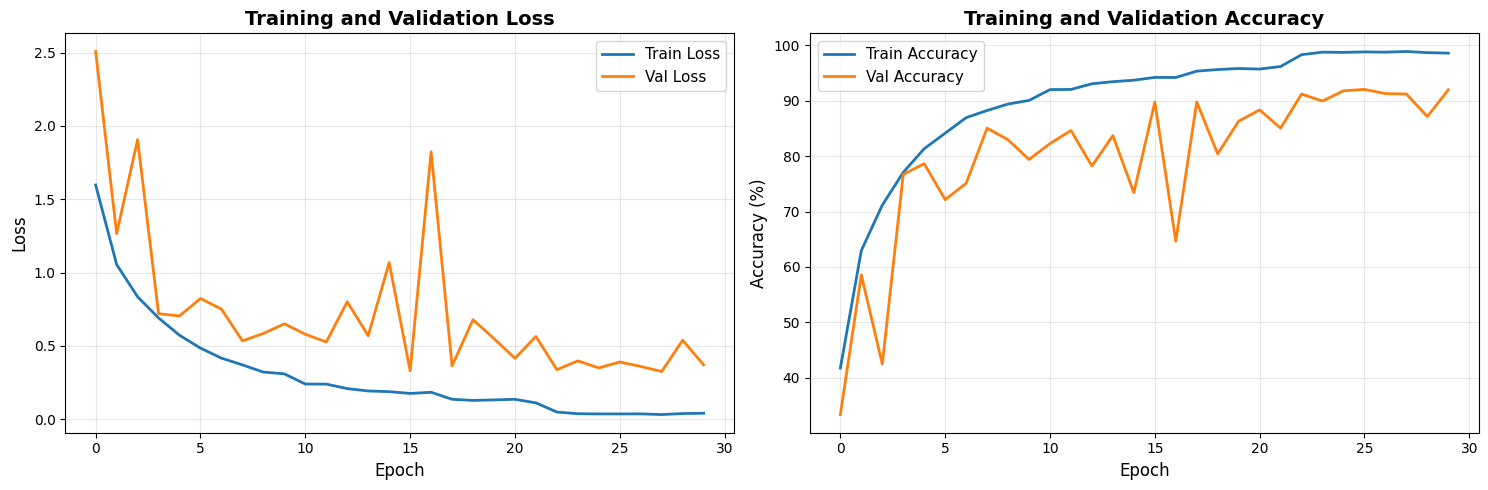

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Лосс
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Валидация модели

In [20]:
# Загружаем лучшую модель

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


test_acc = 100. * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n{'='*60}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"{'='*60}\n")

Testing:   0%|          | 0/27 [00:00<?, ?it/s]


Test Accuracy: 78.49%



Вероятно на 50 эпохах смогла бы выбить accuracy 80

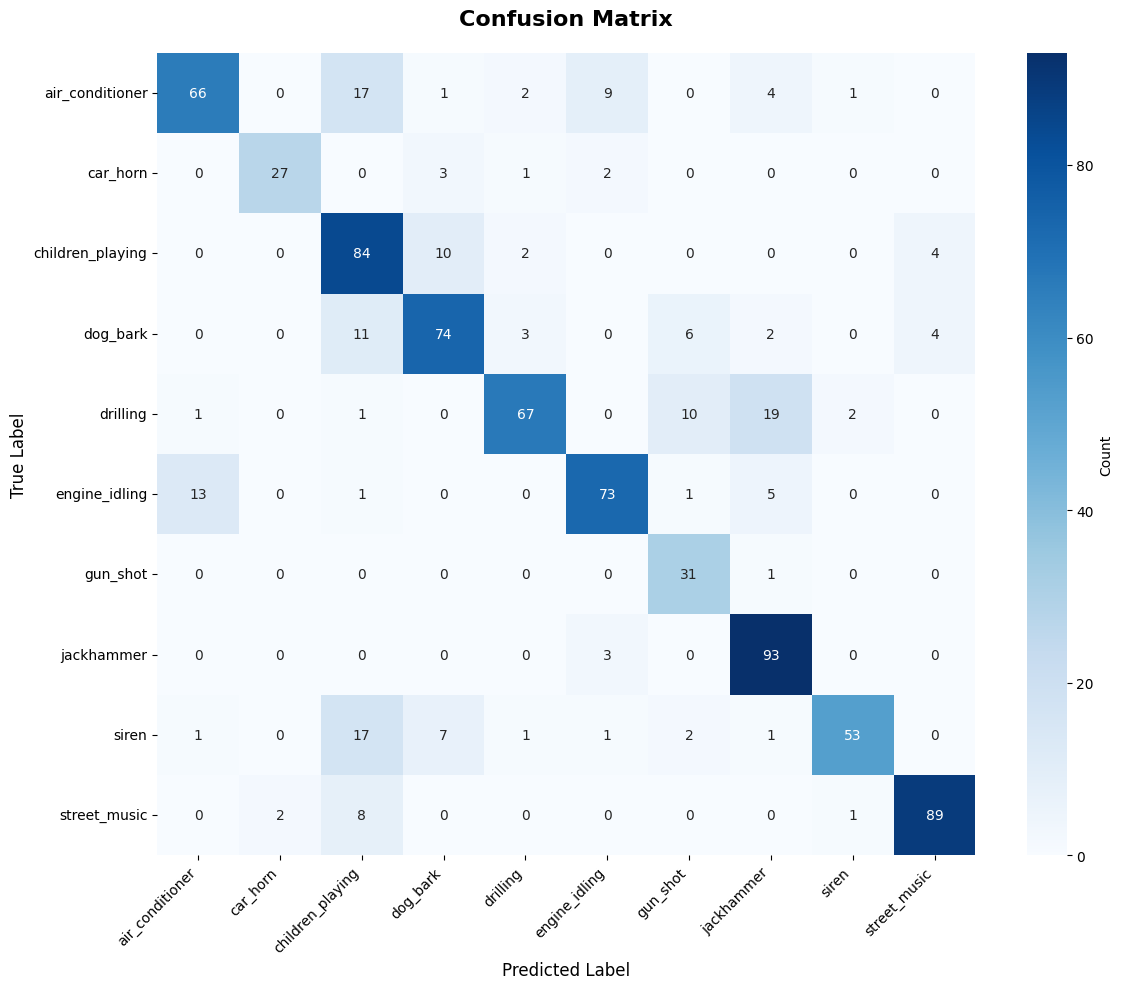

In [27]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
class_names = test_dataset.label_encoder.classes_

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

                  precision    recall  f1-score   support

 air_conditioner     0.8148    0.6600    0.7293       100
        car_horn     0.9310    0.8182    0.8710        33
children_playing     0.6043    0.8400    0.7029       100
        dog_bark     0.7789    0.7400    0.7590       100
        drilling     0.8816    0.6700    0.7614       100
   engine_idling     0.8295    0.7849    0.8066        93
        gun_shot     0.6200    0.9688    0.7561        32
      jackhammer     0.7440    0.9688    0.8416        96
           siren     0.9298    0.6386    0.7571        83
    street_music     0.9175    0.8900    0.9036       100

        accuracy                         0.7849       837
       macro avg     0.8052    0.7979    0.7889       837
    weighted avg     0.8077    0.7849    0.7852       837



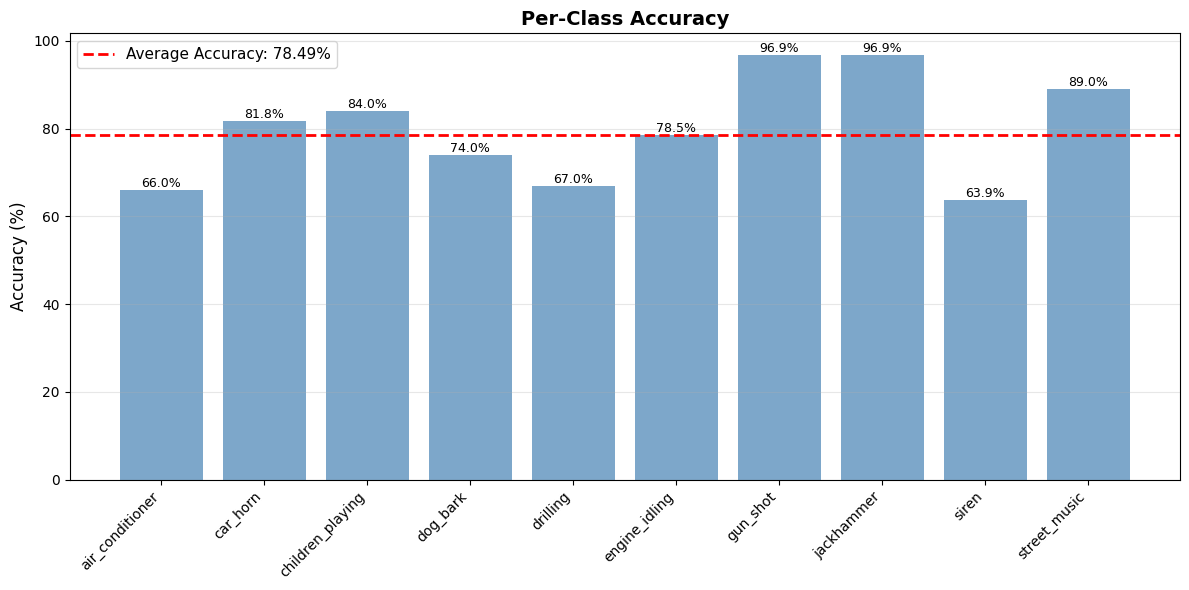

In [31]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100


plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(class_names)), per_class_acc, color='steelblue', alpha=0.7)
plt.axhline(y=test_acc, color='red', linestyle='--', label=f'Average Accuracy: {test_acc:.2f}%', linewidth=2)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{per_class_acc[i]:.1f}%',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# Разбалловка части с метрикой

assert test_acc >= 0.65 # 0.5 * 3 баллов
assert test_acc >= 0.7 # 0.6 * 3 баллов
assert test_acc >= 0.75 # 0.7 * 3 баллов
assert test_acc >= 0.8 # 0.8 * 3 баллов
assert test_acc >= 0.85 # 0.9 * 3 баллов
assert test_acc >= 0.9 # 1 * 3 баллов
print(f"Accuracy: {test_acc:.4f}")

Accuracy: 78.4946


In [25]:
torch.save(model.state_dict(), 'best_model.pth')

In [26]:
from IPython.display import FileLink
FileLink('best_model.pth')

/kaggle/working/best_model.pth